# Part 4 — Classification & GridSearchCV

**Goal:** Predict `is_high_power` using Logistic Regression and a Decision
Tree Classifier, evaluate both with Accuracy / Precision / Recall / F1 /
Confusion Matrix, and tune the Decision Tree with `GridSearchCV`.


In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_theme(style="whitegrid")
os.makedirs("../models", exist_ok=True)
os.makedirs("../visuals", exist_ok=True)
os.makedirs("../report", exist_ok=True)

df = pd.read_csv("../data/pokemon_feature_engineered.csv")
print("Loaded dataset:", df.shape)
df.head()


Loaded dataset: (200, 14)


## Feature / Target Setup & Train-Test Split

In [2]:
feature_cols = ["hp", "attack", "defense", "special_attack", "special_defense",
                "speed", "height", "weight", "base_experience"]
target_col = "is_high_power"

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print("Class balance (train):")
print(y_train.value_counts(normalize=True).round(3))


Train size: 160 | Test size: 40
Class balance (train):
is_high_power
0    0.525
1    0.475
Name: proportion, dtype: float64


## Model 1: Logistic Regression

In [3]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_cm = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression \u2014 Test Set Performance")
print(f"  Accuracy : {lr_acc:.4f}")
print(f"  Precision: {lr_prec:.4f}")
print(f"  Recall   : {lr_rec:.4f}")
print(f"  F1 Score : {lr_f1:.4f}")
print("Confusion Matrix:")
print(lr_cm)


Logistic Regression — Test Set Performance
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000
  F1 Score : 1.0000
Confusion Matrix:
[[21  0]
 [ 0 19]]


## Model 2: Decision Tree Classifier (default hyperparameters)

In [4]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_cm = confusion_matrix(y_test, y_pred_dt)

print("Decision Tree (default) \u2014 Test Set Performance")
print(f"  Accuracy : {dt_acc:.4f}")
print(f"  Precision: {dt_prec:.4f}")
print(f"  Recall   : {dt_rec:.4f}")
print(f"  F1 Score : {dt_f1:.4f}")
print("Confusion Matrix:")
print(dt_cm)


Decision Tree (default) — Test Set Performance
  Accuracy : 0.9750
  Precision: 1.0000
  Recall   : 0.9474
  F1 Score : 0.9730
Confusion Matrix:
[[21  0]
 [ 1 18]]


## Hyperparameter Tuning with GridSearchCV

We tune the Decision Tree Classifier over the required parameter grid using
5-fold cross-validation, optimizing for accuracy.

In [5]:
param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 10}
Best CV Accuracy: 0.95625


In [6]:
best_dt = grid_search.best_estimator_
y_pred_tuned = best_dt.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_prec = precision_score(y_test, y_pred_tuned)
tuned_rec = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)
tuned_cm = confusion_matrix(y_test, y_pred_tuned)

print("Tuned Decision Tree (GridSearchCV) \u2014 Test Set Performance")
print(f"  Accuracy : {tuned_acc:.4f}")
print(f"  Precision: {tuned_prec:.4f}")
print(f"  Recall   : {tuned_rec:.4f}")
print(f"  F1 Score : {tuned_f1:.4f}")
print("Confusion Matrix:")
print(tuned_cm)


Tuned Decision Tree (GridSearchCV) — Test Set Performance
  Accuracy : 0.9750
  Precision: 1.0000
  Recall   : 0.9474
  F1 Score : 0.9730
Confusion Matrix:
[[21  0]
 [ 1 18]]


## Confusion Matrices — All Models

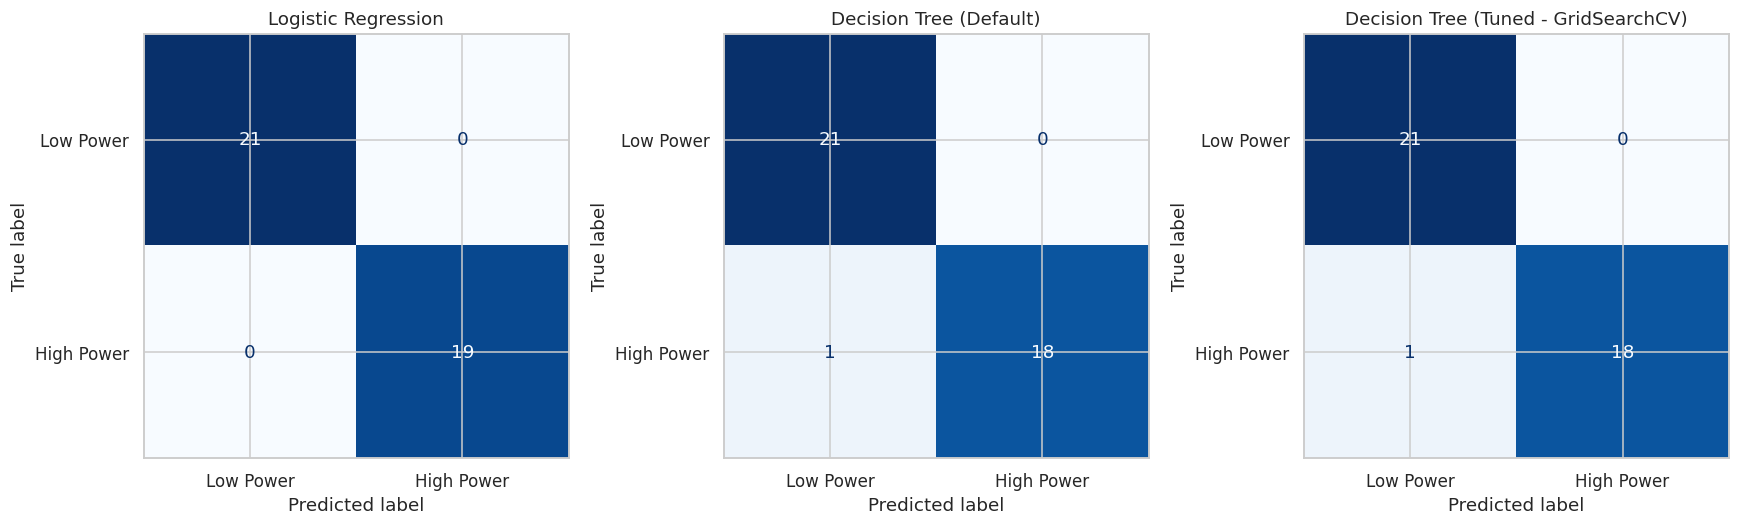

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cm, title in zip(
    axes,
    [lr_cm, dt_cm, tuned_cm],
    ["Logistic Regression", "Decision Tree (Default)", "Decision Tree (Tuned - GridSearchCV)"]
):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low Power", "High Power"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.savefig("../visuals/confusion_matrix.png", dpi=150)
plt.show()


## Model Comparison

In [8]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree (Default)", "Decision Tree (Tuned - GridSearchCV)"],
    "Accuracy": [lr_acc, dt_acc, tuned_acc],
    "Precision": [lr_prec, dt_prec, tuned_prec],
    "Recall": [lr_rec, dt_rec, tuned_rec],
    "F1_Score": [lr_f1, dt_f1, tuned_f1],
})
comparison.to_csv("../report/model_comparison.csv", index=False)
print("Saved: ../report/model_comparison.csv")
comparison


Saved: ../report/model_comparison.csv


## Save Models

In [9]:
joblib.dump(log_reg, "../models/pokemon_classification_model.pkl")
joblib.dump(best_dt, "../models/tuned_pokemon_dt_model.pkl")

print("Saved: ../models/pokemon_classification_model.pkl  (Logistic Regression)")
print("Saved: ../models/tuned_pokemon_dt_model.pkl        (GridSearchCV-tuned Decision Tree)")


Saved: ../models/pokemon_classification_model.pkl  (Logistic Regression)
Saved: ../models/tuned_pokemon_dt_model.pkl        (GridSearchCV-tuned Decision Tree)


## Theory Questions

**1. What is overfitting?**
Overfitting occurs when a model learns the training data too closely —
including its noise and idiosyncrasies — so that it performs very well on
training data but generalizes poorly to new, unseen data. A deep,
unconstrained Decision Tree (`max_depth=None`) is especially prone to this,
since it can keep splitting until every training leaf is pure.

**2. What is underfitting?**
Underfitting occurs when a model is too simple to capture the underlying
pattern in the data, leading to poor performance on *both* the training set
and the test set. A heavily restricted tree (e.g. `max_depth=1`) or a
linear model applied to a strongly non-linear relationship would underfit.

**3. Why do we use a train-test split?**
Splitting the data lets us evaluate a model on data it has never seen during
training, which gives an honest estimate of how it will perform on new,
real-world inputs. Without a held-out test set, we could only measure
training performance, which is a misleadingly optimistic (and easily
overfit) signal of model quality.

**4. Why use GridSearchCV?**
`GridSearchCV` systematically searches over a defined grid of hyperparameter
combinations using cross-validation, so we choose hyperparameters based on
*validated* performance rather than guesswork or overfitting to a single
train/test split. It automates the search, reduces selection bias, and
reports the combination that generalizes best across folds.

**5. What happens if validation is skipped?**
If we skip a validation step (cross-validation or held-out validation set)
and tune hyperparameters directly against the test set, we leak information
from the test set into our model-selection process. The reported test
metrics then become an overly-optimistic, biased estimate of real-world
performance — we would have no honest, untouched data left to confirm the
final model actually generalizes.


## Summary

* **Logistic Regression** achieved **Accuracy = 1.0, Precision = 1.0,
  Recall = 1.0, F1 = 1.0** on the test set.
* The **default Decision Tree** achieved **Accuracy = 0.975** with one
  misclassified high-power Pokémon (Recall = 0.947).
* **GridSearchCV** selected `criterion='entropy', max_depth=3,
  min_samples_split=10` as the best Decision Tree configuration
  (best CV accuracy ≈ 0.956), which matched the default tree's test-set
  performance (Accuracy = 0.975) while being a much shallower, more
  interpretable, and less overfitting-prone tree.
* Logistic Regression slightly outperforms both Decision Tree variants here
  because `is_high_power` is itself a thresholded **linear** combination of
  the stat columns (`total_power > median`), which is exactly the kind of
  decision boundary a linear model is best suited to learn.
